CARGA DE LIBRERIAS E IMPORTACION DE DATOS 

In [173]:
#importamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   
import seaborn as sns 
import math
import os

#Importamos el data frame desde el archivo que usamos para cargar el excel
from cargar_datos import cargarDatos 
df = cargarDatos()
display(df.head())

       tipo_credito      fecha_prestamo  capital_prestado  plazo_meses  \
0                 7 2024-12-21 11:31:35         3692160.0           10   
1                 4 2025-04-22 09:47:35          840000.0            6   
2                 9 2026-01-08 12:22:40         5974028.4           10   
3                 4 2025-08-04 12:04:10         1671240.0            6   
4                 9 2025-04-26 11:24:26         2781636.0           11   
...             ...                 ...               ...          ...   
10758             9 2025-01-19 16:18:28         2414886.0           10   
10759             4 2025-01-10 16:40:21         2916000.0           24   
10760             4 2025-06-19 14:28:47         4249200.0           36   
10761             9 2025-03-02 11:53:41         1283307.6           10   
10762             4 2024-12-08 12:46:03         3915000.0           12   

       edad_cliente   tipo_laboral  salario_cliente  total_otros_prestamos  \
0                42  Independient

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


LIMPIEZA DE DATOS 

In [174]:
#Hacemos una exploración previa de los tipos de datos
print(f"Número de clientes: {df.shape[0]:,}")
print(f"Número de variables: {df.shape[1]}")
print("=" * 70)
df.info()



Número de clientes: 10,763
Número de variables: 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            

In [175]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"\n🔄 DUPLICADOS: {duplicados}")
if duplicados == 0:
    print("✅ No hay registros duplicados")


🔄 DUPLICADOS: 0
✅ No hay registros duplicados


In [176]:
# Eliminamos la columna "huella_consulta" ya que es un dato de identificación 
# que no aporta valor al modelo
df = df.drop(columns=["huella_consulta"])

In [177]:
# Verificar valores nulos
print("\n🔎 VERIFICACIÓN DE VALORES NULOS")
print("=" * 70)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "✅ No hay valores nulos en el dataset")


🔎 VERIFICACIÓN DE VALORES NULOS
puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
dtype: int64


In [178]:

#Verificamos si hay valores nulos y valores en 0
print("\n🔎 VERIFICACIÓN DE VALORES NULOS Y VALORES EN 0")
print("=" * 70)

# Crear tabla de verificación
verificacion = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Valores en 0": (df == 0).sum(numeric_only=False)
})

# Mostrar solo las columnas que tengan nulos o ceros
verificacion = verificacion[
    (verificacion["Nulos"] > 0) | (verificacion["Valores en 0"] > 0)
]

if verificacion.empty:
    print("✅ No hay valores nulos ni valores en 0 en el dataset.")
else:
    display(verificacion)


🔎 VERIFICACIÓN DE VALORES NULOS Y VALORES EN 0


,Nulos,Valores en 0
salario_cliente,0,24
total_otros_prestamos,0,445
puntaje_datacredito,6,145
cant_creditosvigentes,0,405
saldo_mora,156,10552
saldo_total,156,789
saldo_principal,405,633
saldo_mora_codeudor,590,10170
creditos_sectorFinanciero,0,1924
creditos_sectorCooperativo,0,8868


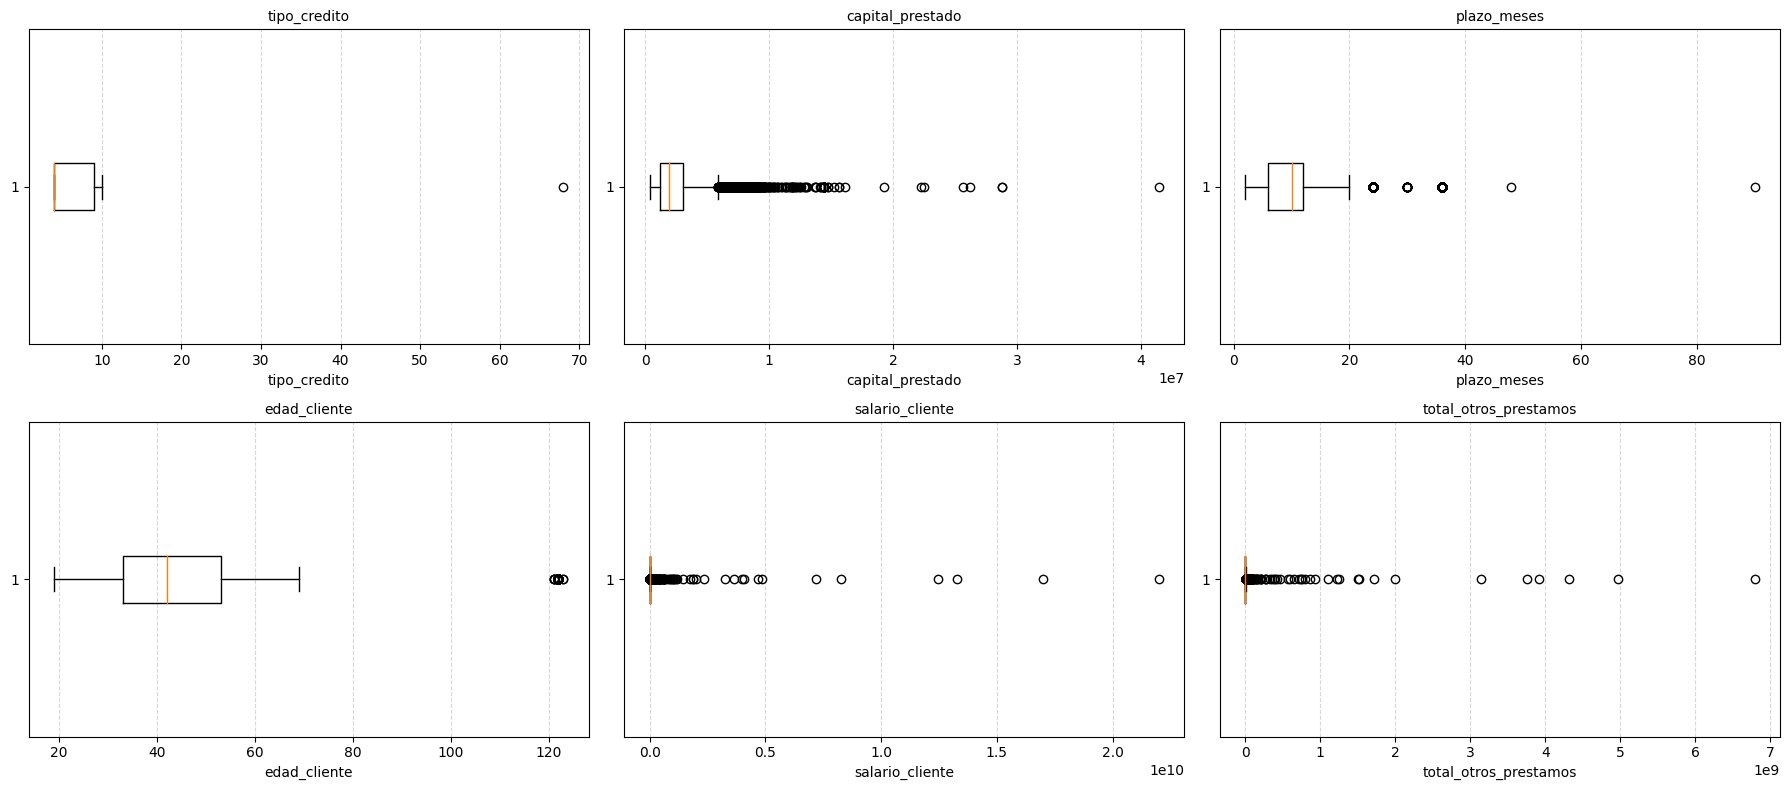

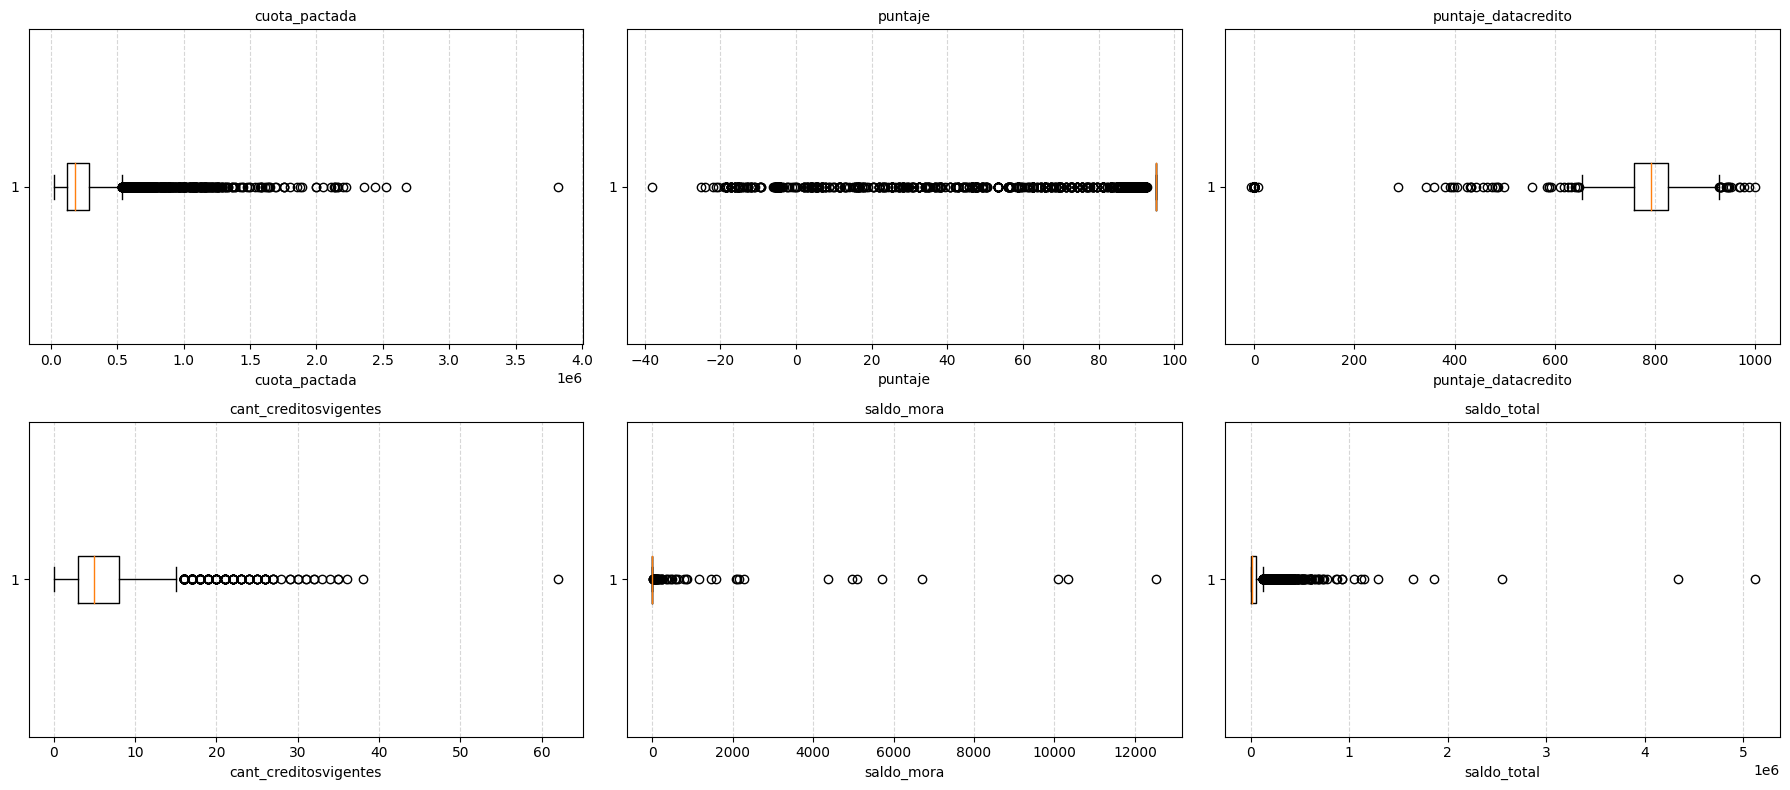

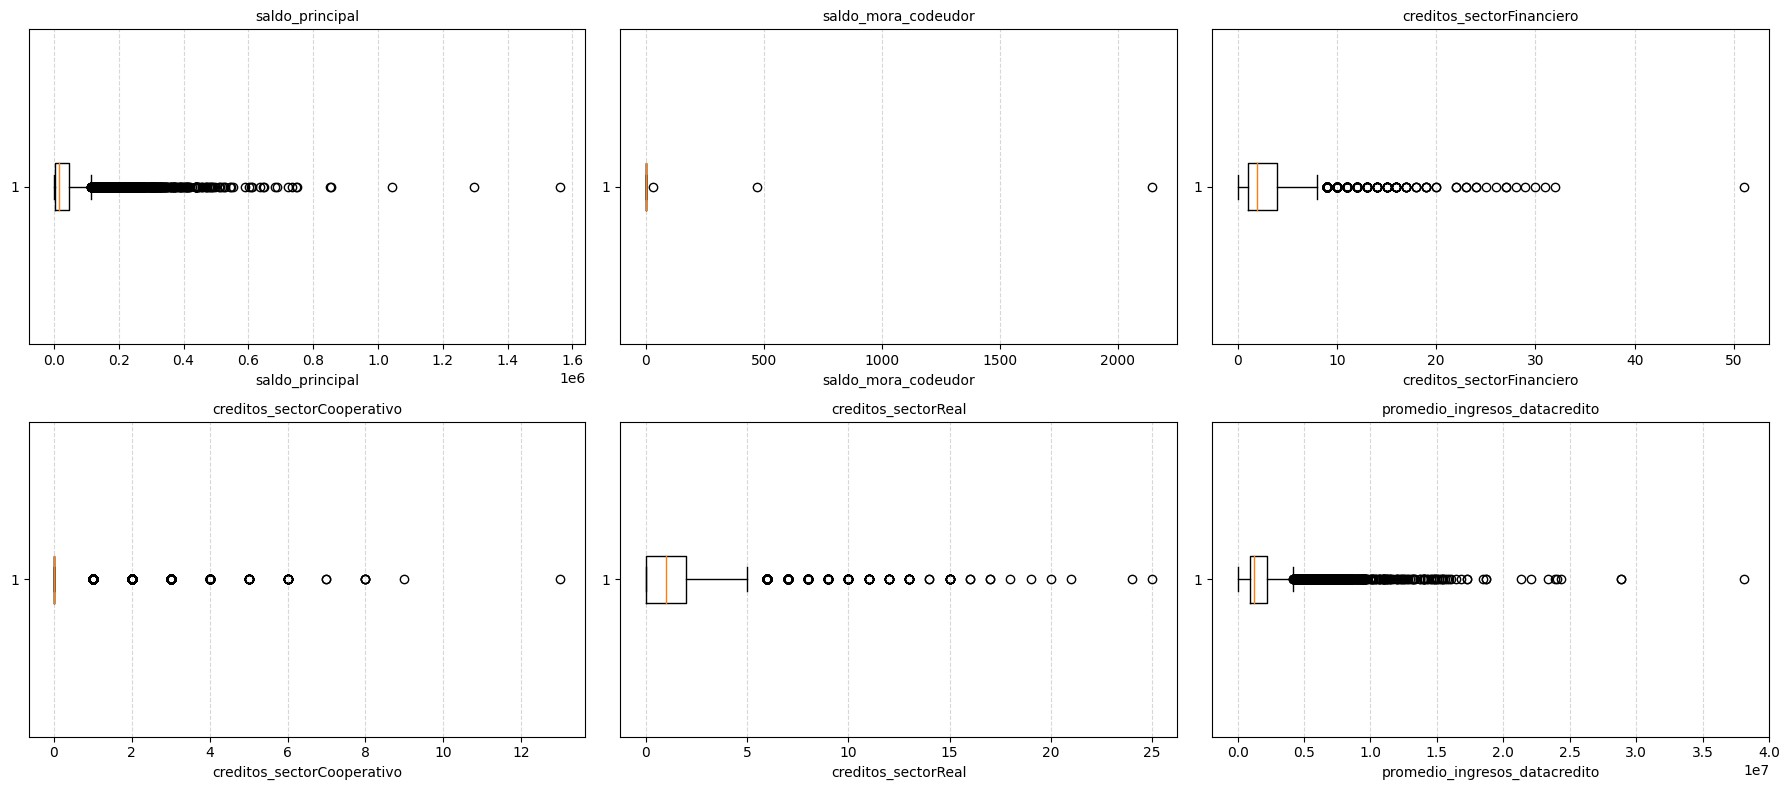

In [179]:
#Para saber si imputar por media o mediana se buscan outliers en las variables numéricas

# Variables numéricas excepto la variable objetivo
columnas = df.select_dtypes(include="number").drop(columns=["Pago_atiempo"]).columns

# Número de gráficas por figura
graficas_por_figura = 6

for i in range(0, len(columnas), graficas_por_figura):

    cols_grupo = columnas[i:i + graficas_por_figura]

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()

    for j, col in enumerate(cols_grupo):
        axes[j].boxplot(df[col].dropna(), vert=False)
        axes[j].set_title(col, fontsize=10)
        axes[j].set_xlabel(col)
        axes[j].grid(axis='x', linestyle='--', alpha=0.5)

    # Eliminar los ejes sobrantes
    for k in range(len(cols_grupo), len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

In [180]:
# Se corrigen los outliers de las variables tipo_credito, edad_cliente, plazo_meses cuyos outliers
# Se pueden inferir como errores de imputación

#Se corrige el valor de tipo de credito 
df["tipo_credito"] = df["tipo_credito"].replace(68, 6)

#Se corrigen los valores de las edades
df["edad_cliente"] = df["edad_cliente"].replace({
    121: 21,
    122: 22,
    123: 23
})
# Se corrige el valor de plazo_meses 
df["plazo_meses"] = df["plazo_meses"].replace(90, 48)


In [181]:
# se eliminan los 24 registros de clientes con salario 0 cuya cantidad es minima y por lo tanto prescindibles
# Contar cuántas filas tienen salario_cliente = 0
filas_eliminadas = (df["salario_cliente"] == 0).sum()

# Eliminar esas filas
df = df[df["salario_cliente"] != 0].reset_index(drop=True)

# Mostrar mensaje
print(f"✅ Se eliminaron {filas_eliminadas} filas con salario_cliente = 0.")
print(f"📊 El DataFrame ahora tiene {len(df)} registros.")

✅ Se eliminaron 24 filas con salario_cliente = 0.
📊 El DataFrame ahora tiene 10739 registros.


In [182]:
# Eliminamos registros nulos que representan una cantidad minima y podemos prescindir de ellos 
#  Columnas donde no se permiten valores nulos
columnas = [
    "puntaje_datacredito",
    "saldo_mora",
    "saldo_total"
]

# Número de registros antes de eliminar
registros_antes = len(df)

# Eliminar filas con valores nulos
df = df.dropna(subset=columnas).reset_index(drop=True)

# Número de registros eliminados
registros_eliminados = registros_antes - len(df)

# Mostrar resultado
print("=" * 70)
print("ELIMINACIÓN DE REGISTROS CON VALORES NULOS")
print("=" * 70)
print(f"✅ Se eliminaron {registros_eliminados} registros con valores nulos en las columnas {columnas}.")
print(f"📊 El DataFrame ahora contiene {len(df)} registros.")

ELIMINACIÓN DE REGISTROS CON VALORES NULOS
✅ Se eliminaron 155 registros con valores nulos en las columnas ['puntaje_datacredito', 'saldo_mora', 'saldo_total'].
📊 El DataFrame ahora contiene 10584 registros.


In [183]:
# Calculamos el porcentaje de registros eliminados

# Registros originales
registros_originales = 10763

# Registros actuales
registros_actuales = len(df)

# Registros eliminados
registros_eliminados = registros_originales - registros_actuales

# Porcentaje eliminado
porcentaje_eliminado = (registros_eliminados / registros_originales) * 100

print("=" * 70)
print(f"🗑️ Registros eliminados : {registros_eliminados}")
print(f"📊 Registros restantes  : {registros_actuales}")
print(f"📉 Porcentaje eliminado : {porcentaje_eliminado:.2f}%")

🗑️ Registros eliminados : 179
📊 Registros restantes  : 10584
📉 Porcentaje eliminado : 1.66%


In [184]:
#imputación de valores nulos usando la mediana debido a la cantidad de outliers
columnas = [
    "saldo_principal",
    "saldo_mora_codeudor",
    "promedio_ingresos_datacredito",
]

for col in columnas:
    df[col] = df[col].fillna(df[col].median())

In [185]:
#la columna tendencia_ingresos es una variable categorica que presenta valores nulos y algunos valores
# numéricos los cuales se convertirán en nulos para despues imputarlos calculando el promedio de la 
# columna promedio_ingresos_datacredito con relación a la columna tendencia_ingresos

#Borramos valores numericos y los dejamos en null
mask = pd.to_numeric(df["tendencia_ingresos"], errors="coerce").notna()

df.loc[mask, "tendencia_ingresos"] = pd.NA

# 1. Calcular el promedio de ingresos por categoría
promedios = (
    df.groupby("tendencia_ingresos")["promedio_ingresos_datacredito"]
      .mean()
)


# 2. Función para asignar la categoría más cercana
def imputar_tendencia(ingreso):
    if pd.isna(ingreso):
        return pd.NA

    diferencias = (promedios - ingreso).abs()
    return diferencias.idxmin()

# 3. Aplicar solo donde tendencia_ingresos es nula
mask = df["tendencia_ingresos"].isna()

df.loc[mask, "tendencia_ingresos"] = (
    df.loc[mask, "promedio_ingresos_datacredito"]
      .apply(imputar_tendencia)
)

In [186]:
# Verificar valores nulos
print("\n🔎 VERIFICACIÓN DE VALORES NULOS")
print("=" * 70)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "✅ No hay valores nulos en el dataset")


🔎 VERIFICACIÓN DE VALORES NULOS
✅ No hay valores nulos en el dataset


In [187]:
# la columna tipo_credito se infiere como una variable categorica la cual es conveniente 
# no contenga valores numericos y se reemplazan por letras

df["tipo_credito"] = df["tipo_credito"].replace({
    4: "A",
    6: "B",
    7: "C",
    9: "D",
    10: "E"
})

In [188]:
# =============================================================================
# FEATURE ENGINEERING DE LA FECHA
# =============================================================================

print("\n📅 Ingeniería de características de la fecha")
print("=" * 70)

df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"])

df["anio_prestamo"] = df["fecha_prestamo"].dt.year

df["mes_prestamo"] = (
    df["fecha_prestamo"]
      .dt.month
      .astype("category")
)

df["trimestre"] = (
    df["fecha_prestamo"]
      .dt.quarter
      .astype("category")
)

df["dia_mes"] = df["fecha_prestamo"].dt.day

df["dia_semana"] = (
    df["fecha_prestamo"]
      .dt.dayofweek
      .astype("category")
)

df["fin_de_semana"] = (
    (df["fecha_prestamo"].dt.dayofweek >= 5)
    .astype("category")
)

df.drop(columns="fecha_prestamo", inplace=True)

print("\n✅ Ingeniería de fecha completada.")
print(f"Columnas actuales: {list(df.columns)}")


📅 Ingeniería de características de la fecha

✅ Ingeniería de fecha completada.
Columnas actuales: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'Pago_atiempo', 'anio_prestamo', 'mes_prestamo', 'trimestre', 'dia_mes', 'dia_semana', 'fin_de_semana']


In [189]:
#calculamos medidas de tendencia central y percentiles 
df.describe()

print("\n💡 Observaciones iniciales:")
print(f"   • Edad: Clientes entre {df['edad_cliente'].min():.0f} y {df['edad_cliente'].max():.0f} años")
print(f"   • Salario cliente: Rango de {df['salario_cliente'].min():.0f} a {df['salario_cliente'].max():.0f}")



💡 Observaciones iniciales:
   • Edad: Clientes entre 19 y 69 años
   • Salario cliente: Rango de 1000 a 22000000000


ANALISIS EXPLORATORIO DE DATOS (EDA)

ANALISIS DE LA VARIABLE OBJERTIVO (Pago_atiempo)

🎯 ANÁLISIS DE LA VARIABLE OBJETIVO (Pago_atiempo)

Clientes que NO pagan a tiempo (0): 499 (4.71%)
Clientes que SÍ pagan a tiempo (1): 10,085 (95.29%)

Tasa de pago a tiempo: 95.29%
Ratio de clases: 0.05:1


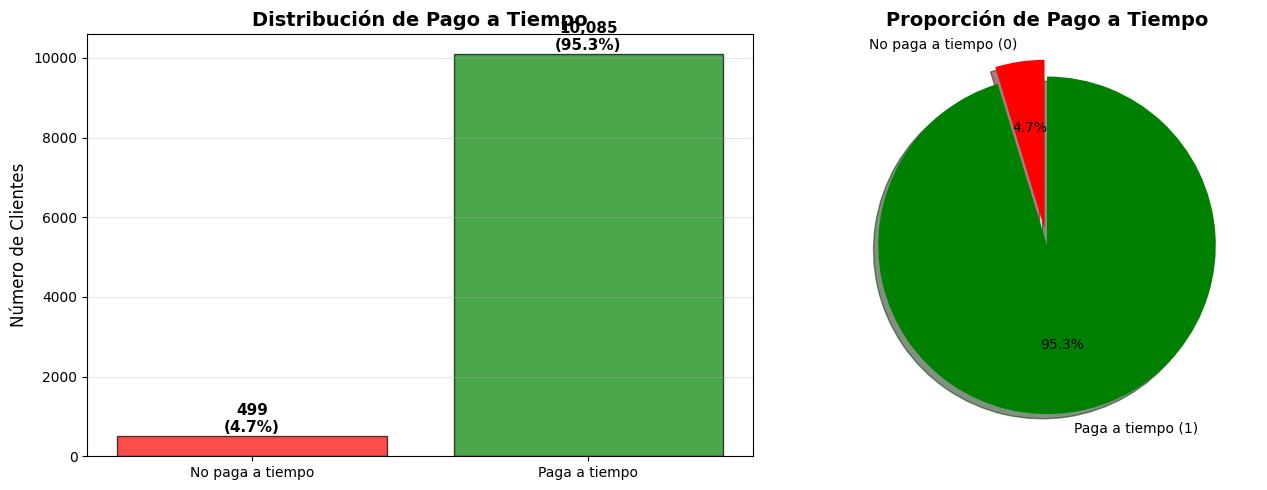


⚠️ DESBALANCEO DE CLASES:
   • Dataset MUY DESBALANCEADO: la clase minoritaria representa solo el 4.7% de los registros.
   • Impacto: El modelo puede aprender a predecir casi siempre la clase mayoritaria.
   • Recomendación: Utilizar ademas de Acuracy tambien Precision, Recall, F1-Score, ROC-AUC


In [190]:
import matplotlib.pyplot as plt

# Distribución de la variable objetivo
pago_counts = df["Pago_atiempo"].value_counts().sort_index()
pago_percentages = df["Pago_atiempo"].value_counts(normalize=True).sort_index() * 100

print("🎯 ANÁLISIS DE LA VARIABLE OBJETIVO (Pago_atiempo)")
print("=" * 70)

print(f"\nClientes que NO pagan a tiempo (0): {pago_counts[0]:,} ({pago_percentages[0]:.2f}%)")
print(f"Clientes que SÍ pagan a tiempo (1): {pago_counts[1]:,} ({pago_percentages[1]:.2f}%)")

print(f"\nTasa de pago a tiempo: {pago_percentages[1]:.2f}%")
print(f"Ratio de clases: {pago_counts[0] / pago_counts[1]:.2f}:1")

# ==========================
# Visualización
# ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(
    ["No paga a tiempo", "Paga a tiempo"],
    [pago_counts[0], pago_counts[1]],
    color=["red", "green"],
    alpha=0.7,
    edgecolor="black"
)

axes[0].set_ylabel("Número de Clientes", fontsize=12)
axes[0].set_title("Distribución de Pago a Tiempo", fontsize=14, fontweight="bold")
axes[0].grid(alpha=0.3, axis="y")

for i, v in enumerate([pago_counts[0], pago_counts[1]]):
    porcentaje = [pago_percentages[0], pago_percentages[1]][i]
    axes[0].text(
        i,
        v + max(pago_counts) * 0.01,
        f"{v:,}\n({porcentaje:.1f}%)",
        ha="center",
        fontweight="bold",
        fontsize=11
    )

# Gráfico de pastel
axes[1].pie(
    [pago_counts[0], pago_counts[1]],
    labels=["No paga a tiempo (0)", "Paga a tiempo (1)"],
    autopct="%1.1f%%",
    colors=["red", "green"],
    startangle=90,
    explode=(0.1, 0),
    shadow=True
)

axes[1].set_title("Proporción de Pago a Tiempo", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

# ==========================
# Análisis del desbalanceo
# ==========================

print("\n⚠️ DESBALANCEO DE CLASES:")

porcentaje_minoritario = pago_percentages.min()

if porcentaje_minoritario < 10:
    print(f"   • Dataset MUY DESBALANCEADO: la clase minoritaria representa solo el {porcentaje_minoritario:.1f}% de los registros.")
    print("   • Impacto: El modelo puede aprender a predecir casi siempre la clase mayoritaria.")
    print("   • Recomendación: Utilizar ademas de Acuracy tambien Precision, Recall, F1-Score, ROC-AUC")

elif porcentaje_minoritario < 30:
    print(f"   • Dataset moderadamente desbalanceado: la clase minoritaria representa el {porcentaje_minoritario:.1f}% de los registros.")
    print("   • Se recomienda evaluar con métricas distintas al Accuracy.")

else:
    print("   • Dataset relativamente balanceado.")

In [191]:
# Variables numéricas (excluyendo la variable objetivo)
numerical_vars = df.select_dtypes(include=["number"]).columns.drop("Pago_atiempo").tolist()

# Variables categóricas
categorical_vars = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Mostrar resultados
print("🔢 Variables numéricas:")
print(numerical_vars)

print("\n📝 Variables categóricas:")
print(categorical_vars)

print(f"\nTotal de variables numéricas: {len(numerical_vars)}")
print(f"Total de variables categóricas: {len(categorical_vars)}")

🔢 Variables numéricas:
['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'anio_prestamo', 'dia_mes']

📝 Variables categóricas:
['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'mes_prestamo', 'trimestre', 'dia_semana', 'fin_de_semana']

Total de variables numéricas: 19
Total de variables categóricas: 7


C:\Users\isaac\AppData\Local\Temp\ipykernel_29320\1325978633.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pago_categoria = df.groupby(var)["Pago_atiempo"].agg(["sum", "count", "mean"])
C:\Users\isaac\AppData\Local\Temp\ipykernel_29320\1325978633.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pago_categoria = df.groupby(var)["Pago_atiempo"].agg(["sum", "count", "mean"])
C:\Users\isaac\AppData\Local\Temp\ipykernel_29320\1325978633.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavi

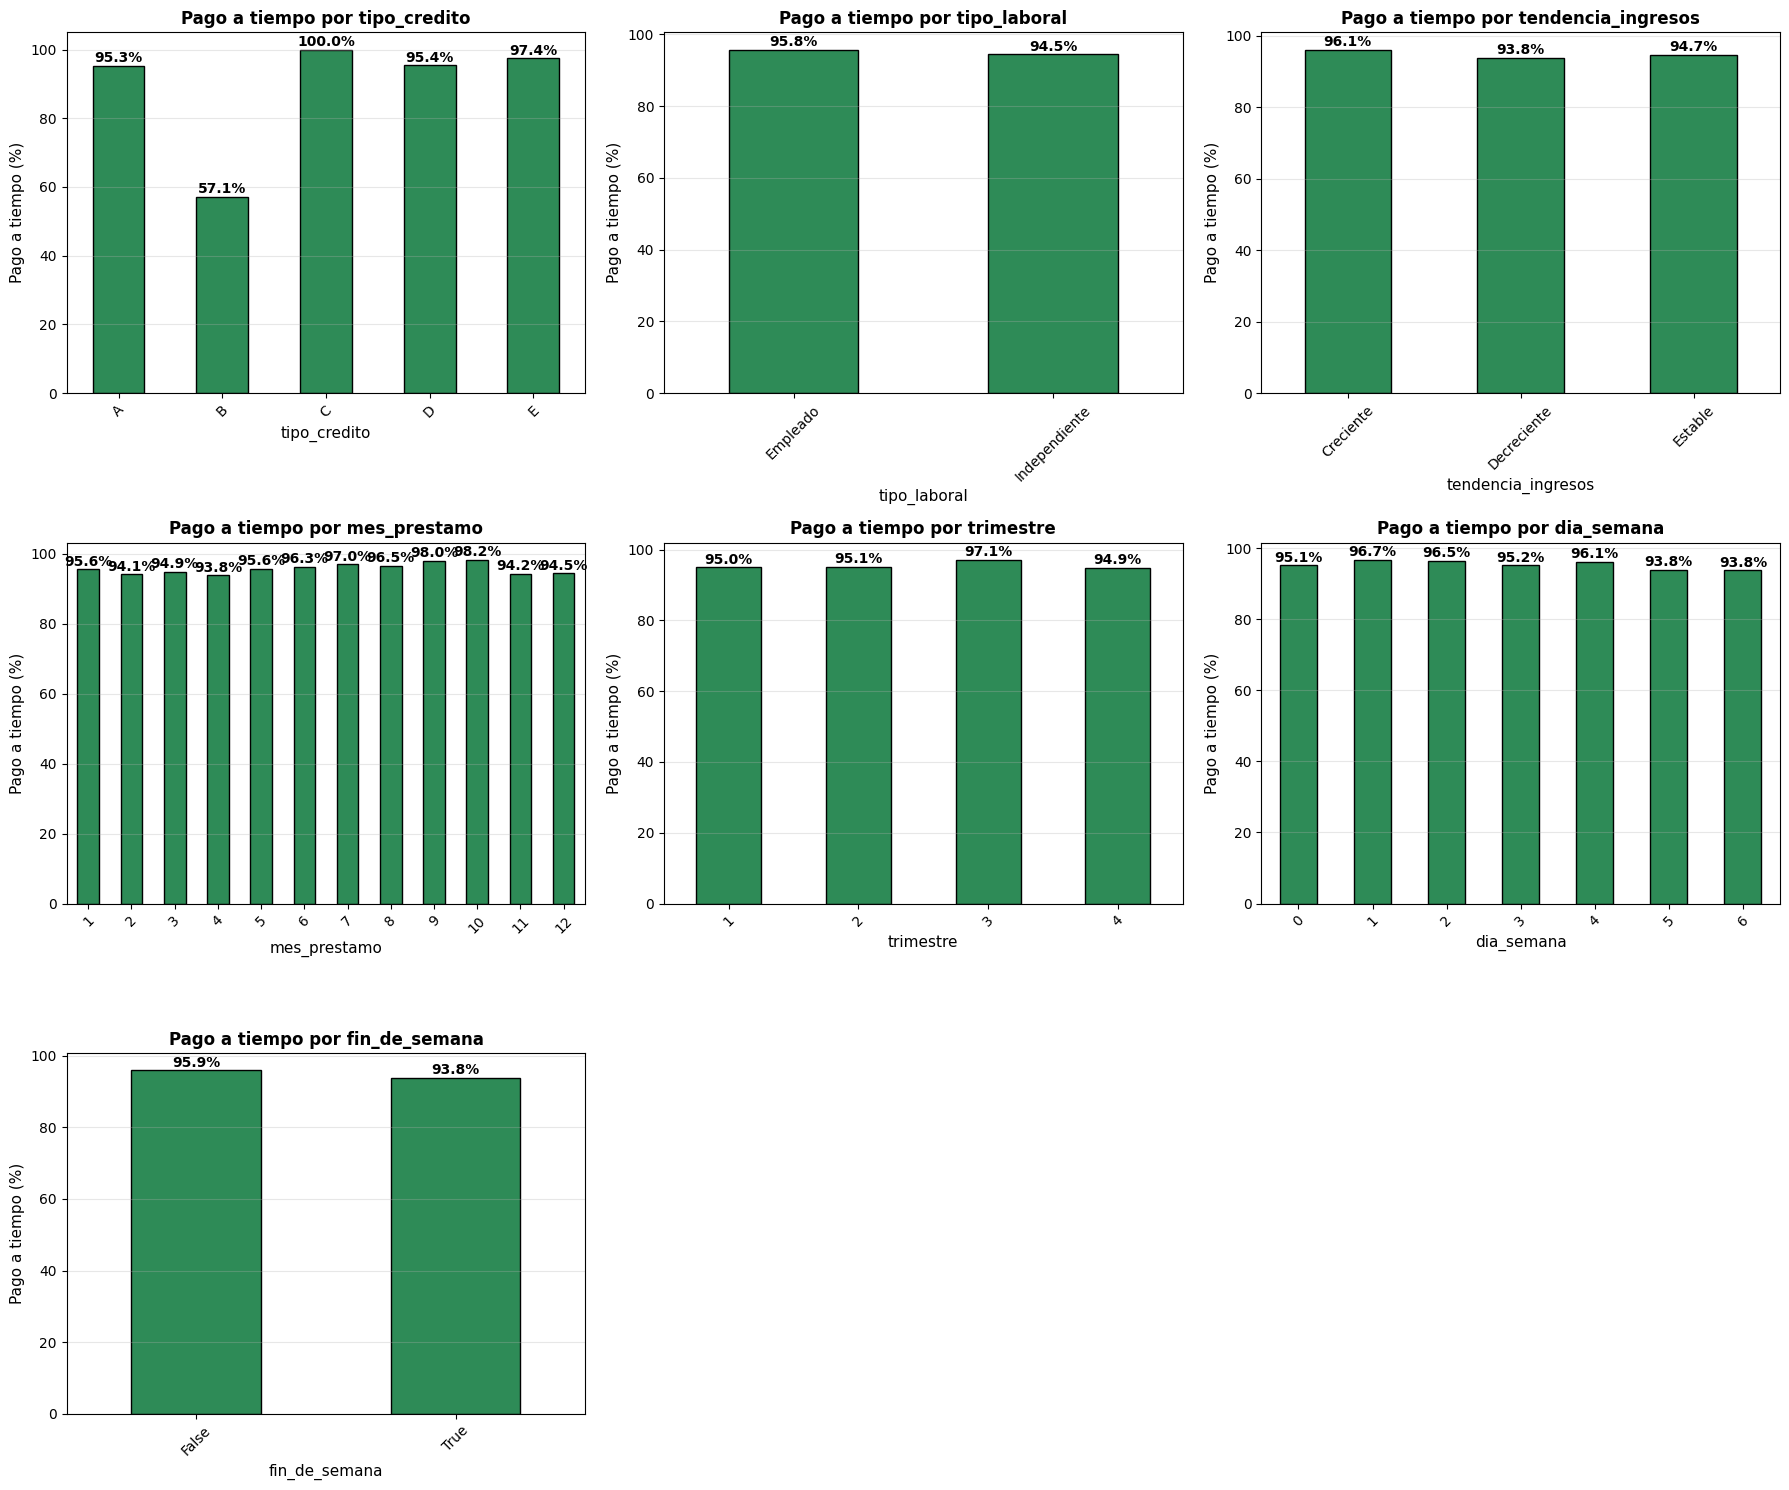


📊 ANÁLISIS DE VARIABLES CATEGÓRICAS

📌 tipo_credito
   ✔ Mayor porcentaje de pago a tiempo : 'C' (100.0%)
   ✖ Menor porcentaje de pago a tiempo : 'B' (57.1%)

📌 tipo_laboral
   ✔ Mayor porcentaje de pago a tiempo : 'Empleado' (95.8%)
   ✖ Menor porcentaje de pago a tiempo : 'Independiente' (94.5%)

📌 tendencia_ingresos
   ✔ Mayor porcentaje de pago a tiempo : 'Creciente' (96.1%)
   ✖ Menor porcentaje de pago a tiempo : 'Decreciente' (93.8%)

📌 mes_prestamo
   ✔ Mayor porcentaje de pago a tiempo : '10' (98.2%)
   ✖ Menor porcentaje de pago a tiempo : '4' (93.8%)

📌 trimestre
   ✔ Mayor porcentaje de pago a tiempo : '3' (97.1%)
   ✖ Menor porcentaje de pago a tiempo : '4' (94.9%)

📌 dia_semana
   ✔ Mayor porcentaje de pago a tiempo : '1' (96.7%)
   ✖ Menor porcentaje de pago a tiempo : '6' (93.8%)

📌 fin_de_semana
   ✔ Mayor porcentaje de pago a tiempo : 'False' (95.9%)
   ✖ Menor porcentaje de pago a tiempo : 'True' (93.8%)


C:\Users\isaac\AppData\Local\Temp\ipykernel_29320\1325978633.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pago_categoria = df.groupby(var)["Pago_atiempo"].mean() * 100
C:\Users\isaac\AppData\Local\Temp\ipykernel_29320\1325978633.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pago_categoria = df.groupby(var)["Pago_atiempo"].mean() * 100
C:\Users\isaac\AppData\Local\Temp\ipykernel_29320\1325978633.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the f

In [192]:
# Análisis de variables categóricas
# ===============================================

# Número de gráficos necesarios
n_vars = len(categorical_vars)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.ravel()

for idx, var in enumerate(categorical_vars):

    # Calcular porcentaje de clientes que pagan a tiempo por categoría
    pago_categoria = df.groupby(var)["Pago_atiempo"].agg(["sum", "count", "mean"])
    pago_categoria["tasa_pago"] = pago_categoria["mean"] * 100

    # Graficar
    pago_categoria["tasa_pago"].plot(
        kind="bar",
        ax=axes[idx],
        color="seagreen",
        edgecolor="black"
    )

    axes[idx].set_xlabel(var, fontsize=11)
    axes[idx].set_ylabel("Pago a tiempo (%)", fontsize=11)
    axes[idx].set_title(f"Pago a tiempo por {var}", fontsize=12, fontweight="bold")
    axes[idx].grid(alpha=0.3, axis="y")
    axes[idx].tick_params(axis="x", rotation=45)

    # Mostrar porcentaje encima de cada barra
    for i, v in enumerate(pago_categoria["tasa_pago"]):
        axes[idx].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# Ocultar subplots vacíos
for i in range(n_vars, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# ===============================================
# Resumen de resultados
# ===============================================

print("\n📊 ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("=" * 70)

for var in categorical_vars:

    pago_categoria = df.groupby(var)["Pago_atiempo"].mean() * 100

    mejor_categoria = pago_categoria.idxmax()
    mejor_tasa = pago_categoria.max()

    peor_categoria = pago_categoria.idxmin()
    peor_tasa = pago_categoria.min()

    print(f"\n📌 {var}")
    print(f"   ✔ Mayor porcentaje de pago a tiempo : '{mejor_categoria}' ({mejor_tasa:.1f}%)")
    print(f"   ✖ Menor porcentaje de pago a tiempo : '{peor_categoria}' ({peor_tasa:.1f}%)")

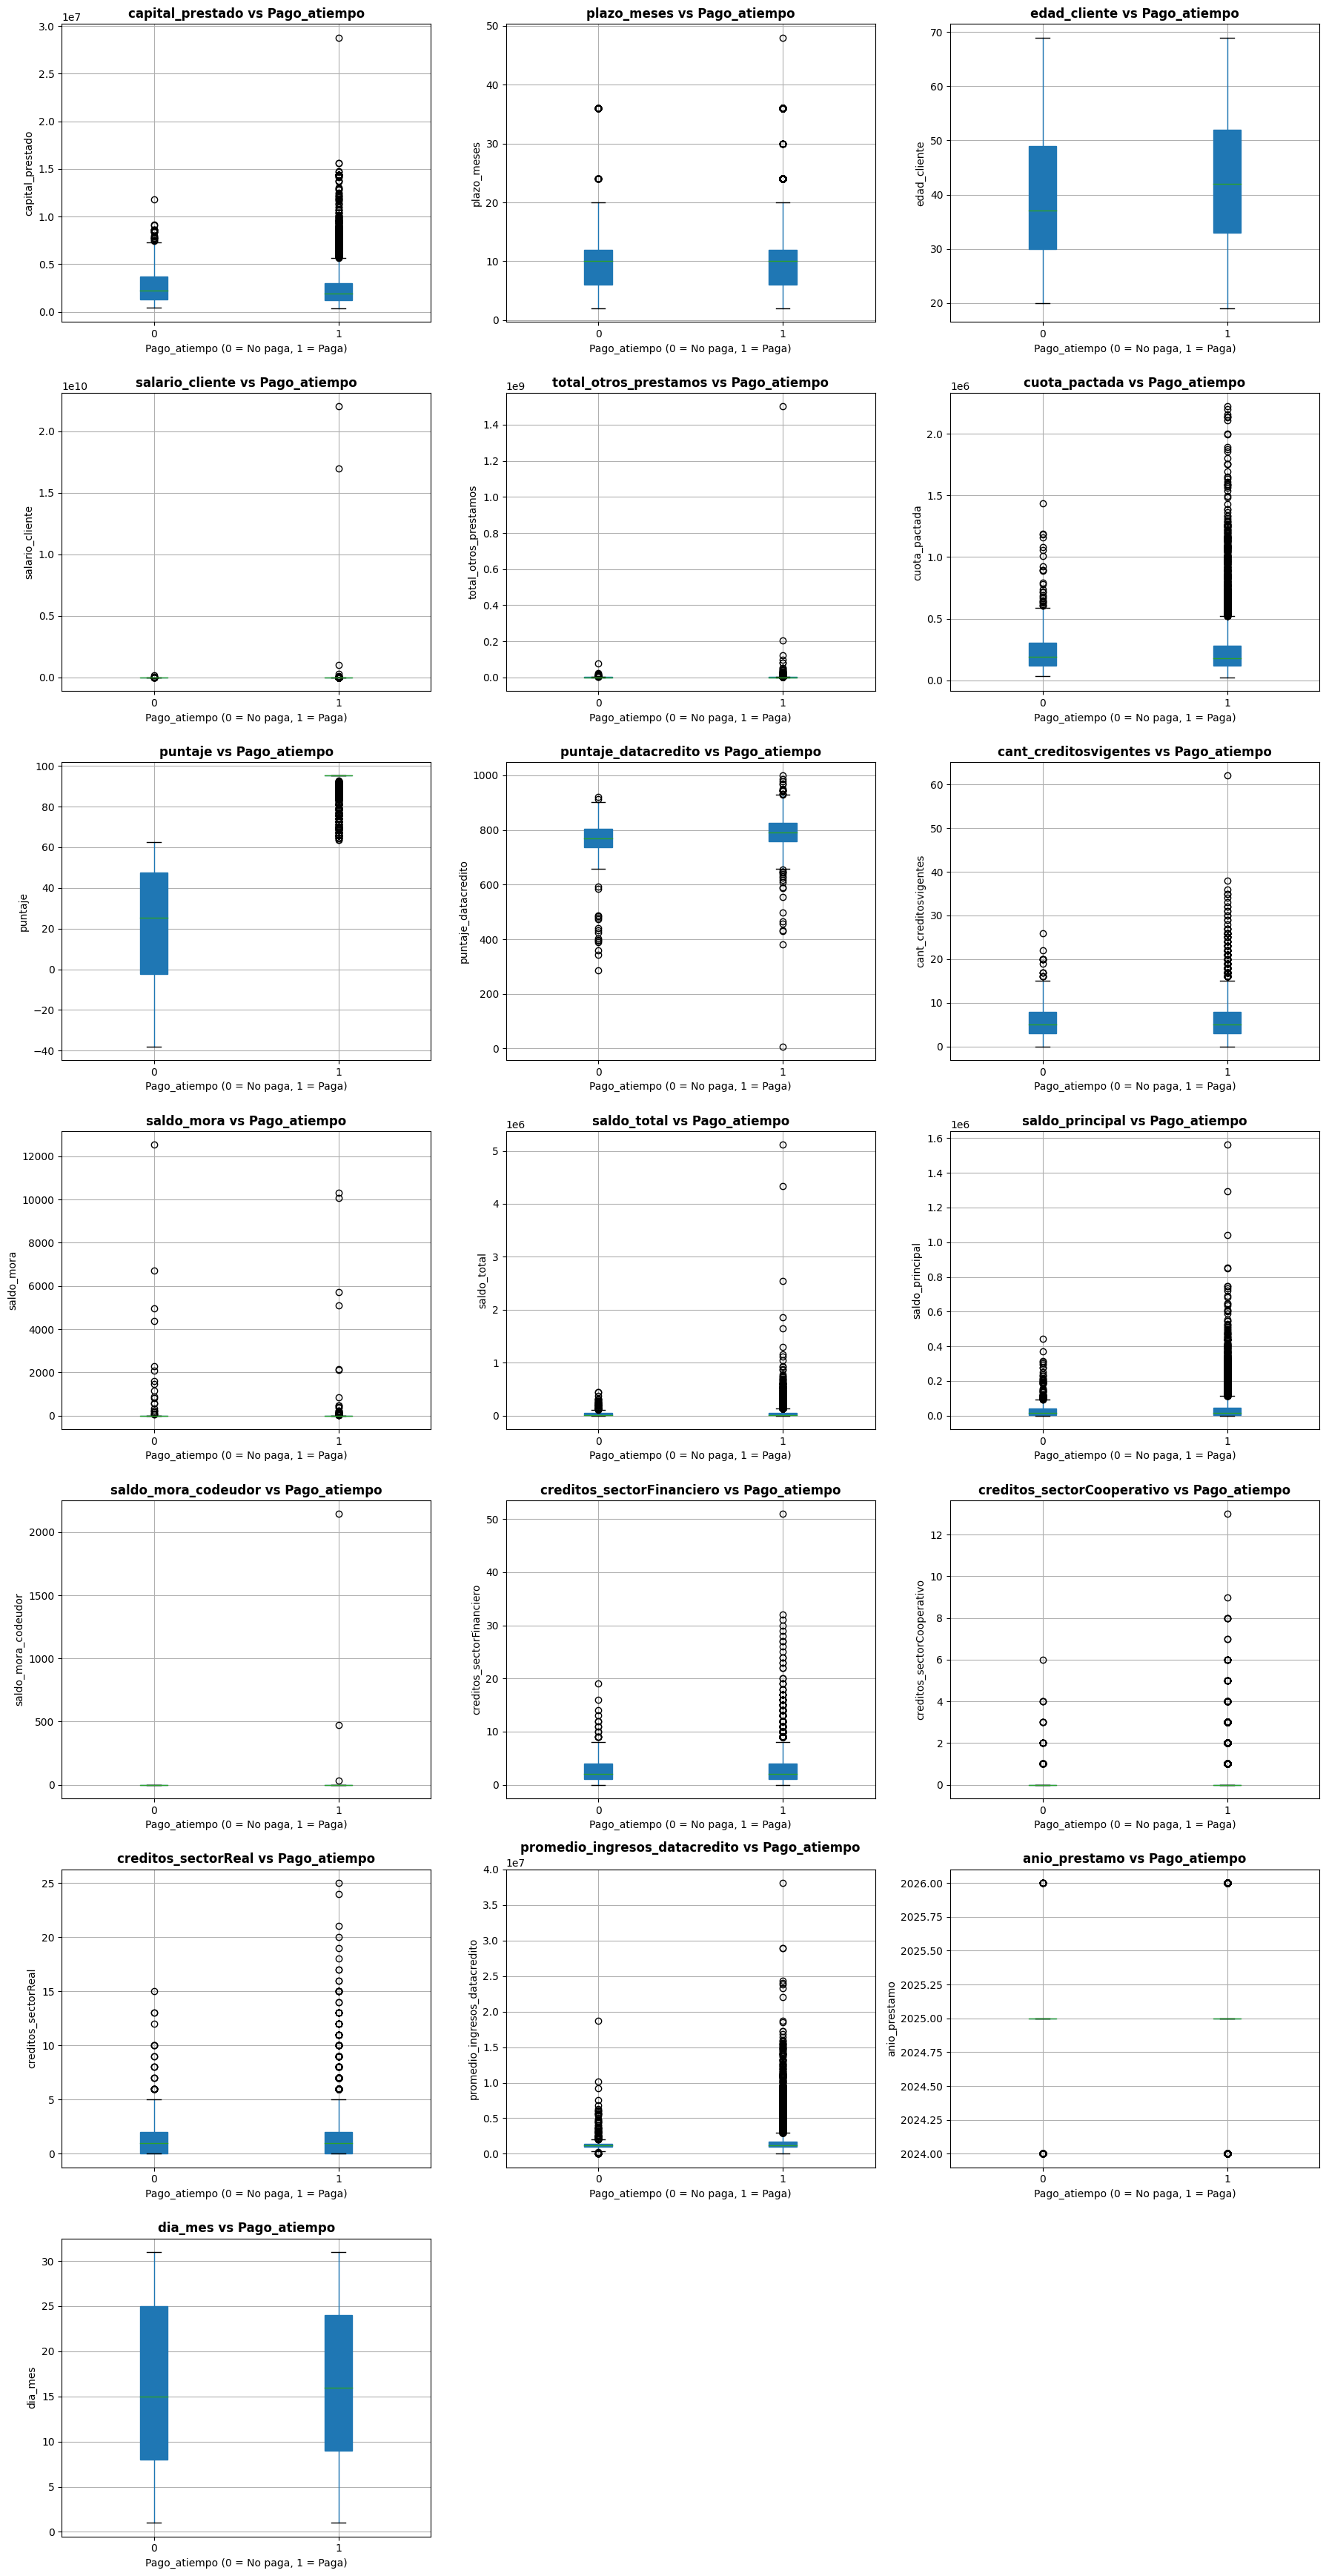


📊 COMPARACIÓN DE MEDIAS
• capital_prestado              No paga =   2757833.18 | Paga =   2363738.80 | Dif =   -394094.39 ( -14.3%)
• plazo_meses                   No paga =        12.55 | Paga =        10.50 | Dif =        -2.05 ( -16.3%)
• edad_cliente                  No paga =        40.00 | Paga =        42.97 | Dif =        +2.97 (  +7.4%)
• salario_cliente               No paga =   4182968.80 | Paga =   7916010.38 | Dif =  +3733041.57 ( +89.2%)
• total_otros_prestamos         No paga =   1591218.48 | Paga =   1690019.43 | Dif =    +98800.94 (  +6.2%)
• cuota_pactada                 No paga =    250678.21 | Paga =    237566.55 | Dif =    -13111.66 (  -5.2%)
• puntaje                       No paga =        23.38 | Paga =        94.57 | Dif =       +71.19 (+304.5%)
• puntaje_datacredito           No paga =       763.62 | Paga =       792.89 | Dif =       +29.27 (  +3.8%)
• cant_creditosvigentes         No paga =         5.68 | Paga =         5.82 | Dif =        +0.14 (  +2.4%)
• s

In [193]:
# ===============================================
# Análisis de variables numéricas
# ===============================================

n_vars = len(numerical_vars)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.ravel()

for idx, var in enumerate(numerical_vars):

    # Boxplot comparando pago a tiempo vs no pago
    df.boxplot(
        column=var,
        by="Pago_atiempo",
        ax=axes[idx],
        patch_artist=True
    )

    axes[idx].set_xlabel("Pago_atiempo (0 = No paga, 1 = Paga)", fontsize=10)
    axes[idx].set_ylabel(var, fontsize=10)
    axes[idx].set_title(f"{var} vs Pago_atiempo", fontsize=12, fontweight="bold")

    # Eliminar el título automático de pandas
    axes[idx].get_figure().suptitle("")

# Ocultar ejes vacíos
for i in range(n_vars, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# ===============================================
# Comparación de medias
# ===============================================

print("\n📊 COMPARACIÓN DE MEDIAS")
print("=" * 100)

for var in numerical_vars:

    media_no_paga = df[df["Pago_atiempo"] == 0][var].mean()
    media_paga = df[df["Pago_atiempo"] == 1][var].mean()

    diferencia = media_paga - media_no_paga

    if media_no_paga != 0:
        diferencia_pct = (diferencia / media_no_paga) * 100
    else:
        diferencia_pct = 0

    print(
        f"• {var:30s}"
        f"No paga = {media_no_paga:12.2f}"
        f" | Paga = {media_paga:12.2f}"
        f" | Dif = {diferencia:+12.2f}"
        f" ({diferencia_pct:+6.1f}%)"
    )


# ===============================================
# Variables con mayor diferencia
# ===============================================

print("\n📌 VARIABLES CON MAYOR DIFERENCIA")
print("=" * 100)

diferencias = []

for var in numerical_vars:

    media_no_paga = df[df["Pago_atiempo"] == 0][var].mean()
    media_paga = df[df["Pago_atiempo"] == 1][var].mean()

    if media_no_paga != 0:
        diferencia_pct = ((media_paga - media_no_paga) / media_no_paga) * 100
    else:
        diferencia_pct = 0

    diferencias.append(
        (
            var,
            media_no_paga,
            media_paga,
            diferencia_pct
        )
    )

# Ordenar por diferencia absoluta
diferencias = sorted(
    diferencias,
    key=lambda x: abs(x[3]),
    reverse=True
)

for var, no_paga, paga, pct in diferencias:
    print(f"• {var:30s}: {pct:+7.2f}%")

A partir de esos resultados, estos son 8 insights que sí están respaldados por los datos.

1. El puntaje interno es el predictor con mayor diferencia entre ambos grupos
Clientes que no pagan a tiempo: 23.38
Clientes que sí pagan a tiempo: 94.57
Diferencia: +304.5%

Insight: El puntaje es la variable con la mayor separación entre las dos clases, por lo que probablemente será una de las variables más importantes para el modelo de clasificación.

2. Los clientes que pagan a tiempo tienen ingresos significativamente mayores
No pagan: $4.18 millones
Pagan: $7.92 millones
Diferencia: +89.2%

Insight: Existe una fuerte asociación entre un mayor salario y el cumplimiento oportuno de las obligaciones crediticias.

3. La mora es mucho menor entre quienes pagan a tiempo
No pagan: 82.53
Pagan: 4.00
Diferencia: −95.2%

Insight: Los clientes que pagan a tiempo presentan prácticamente ausencia de saldo en mora, lo que convierte a esta variable en un fuerte indicador del comportamiento de pago.

4. Los clientes que pagan a tiempo presentan un mejor historial crediticio
Puntaje Datacrédito:
No pagan: 763.62
Pagan: 792.89
Diferencia: +3.8%

Insight: Aunque la diferencia porcentual no es muy grande, los clientes cumplidos muestran sistemáticamente un mejor puntaje en Datacrédito.

5. Los clientes cumplidos reciben préstamos de menor monto
No pagan: $2.76 millones
Pagan: $2.36 millones
Diferencia: −14.3%

Insight: En promedio, quienes pagan a tiempo reciben créditos de menor cuantía, lo que podría indicar un menor nivel de riesgo financiero o políticas de otorgamiento más conservadoras.

6. Los préstamos de menor plazo se asocian con un mejor comportamiento de pago
No pagan: 12.55 meses
Pagan: 10.50 meses
Diferencia: −16.3%

Insight: Los clientes que cumplen con sus pagos suelen tener créditos con plazos más cortos, lo que podría facilitar el cumplimiento de las obligaciones.

7. Los clientes que pagan a tiempo tienen mayores ingresos reportados en Datacrédito
No pagan: $1.47 millones
Pagan: $1.81 millones
Diferencia: +23.3%

Insight: Los ingresos históricos registrados en Datacrédito también son superiores entre los clientes cumplidos, reforzando la relación observada con el salario declarado.

8. La edad presenta una diferencia moderada entre ambos grupos
No pagan: 40.0 años
Pagan: 43.0 años
Diferencia: +7.4%

Insight: En promedio, los clientes que pagan a tiempo son ligeramente mayores. Aunque la diferencia es pequeña en comparación con otras variables, podría aportar información complementaria al modelo.

Variables que parecen tener mayor capacidad predictiva

Con base en las diferencias observadas, las variables que merecen especial atención durante el entrenamiento del modelo son:

puntaje ⭐⭐⭐⭐⭐
salario_cliente ⭐⭐⭐⭐⭐
saldo_mora ⭐⭐⭐⭐⭐
promedio_ingresos_datacredito ⭐⭐⭐⭐
capital_prestado ⭐⭐⭐⭐
plazo_meses ⭐⭐⭐
puntaje_datacredito ⭐⭐⭐
saldo_total ⭐⭐

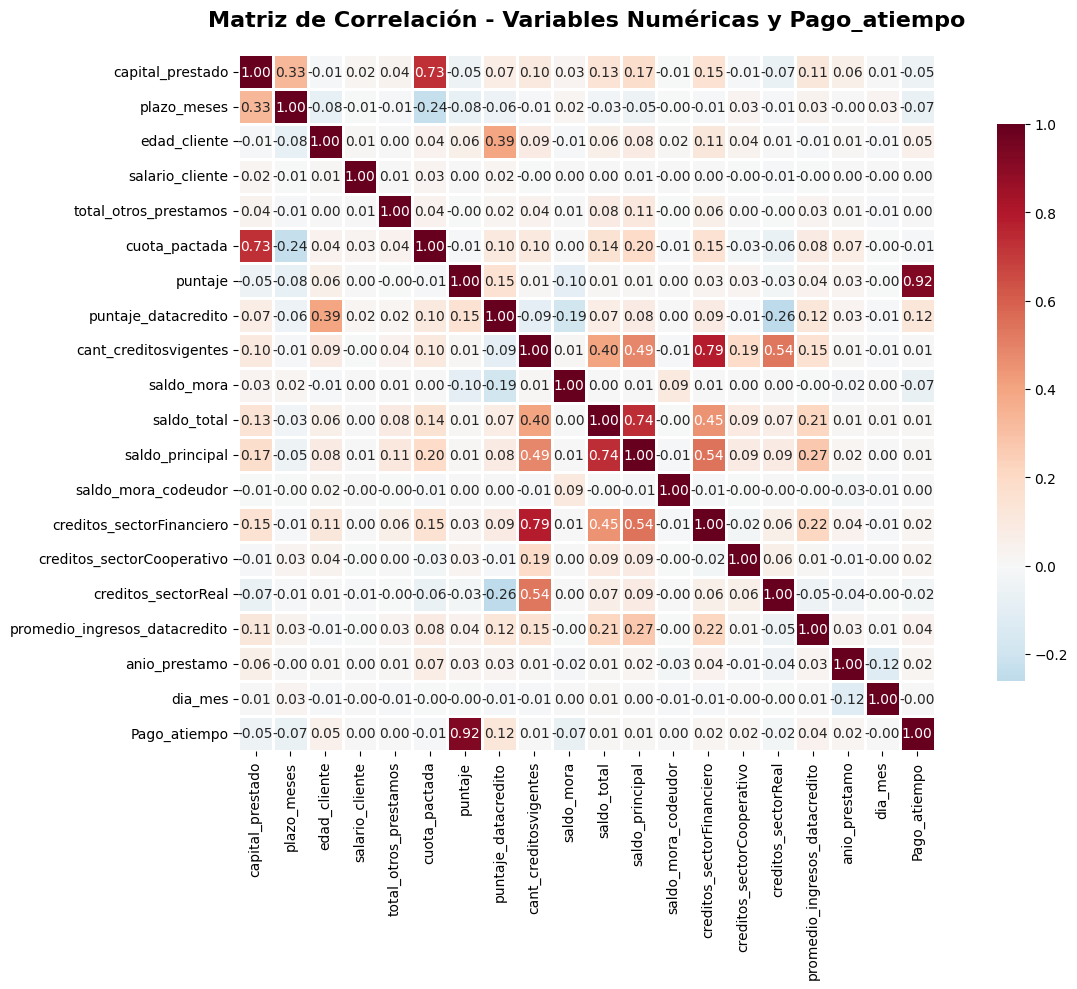


🔗 CORRELACIONES CON PAGO A TIEMPO (Pago_atiempo)
puntaje                          0.923112
puntaje_datacredito              0.120718
saldo_mora                      -0.073616
plazo_meses                     -0.065390
edad_cliente                     0.052715
capital_prestado                -0.047650
promedio_ingresos_datacredito    0.038799
creditos_sectorReal             -0.024795
creditos_sectorFinanciero        0.021273
creditos_sectorCooperativo       0.020698
anio_prestamo                    0.020495
saldo_total                      0.014210
cuota_pactada                   -0.014152
saldo_principal                  0.012052
cant_creditosvigentes            0.007459
salario_cliente                  0.002927
saldo_mora_codeudor              0.002604
total_otros_prestamos            0.001397
dia_mes                         -0.000378
Name: Pago_atiempo, dtype: float64

💡 VARIABLES CON MAYOR RELACIÓN CON Pago_atiempo
• puntaje: 0.923 (correlación positiva)
• puntaje_datacredito: 0.121

In [194]:
# ===============================================
# Matriz de correlación incluyendo Pago_atiempo
# ===============================================

# Variables numéricas + variable objetivo
correlation_vars = numerical_vars + ["Pago_atiempo"]

# Crear matriz de correlación
corr_matrix = df[correlation_vars].corr()

# Visualización
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Matriz de Correlación - Variables Numéricas y Pago_atiempo",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()


# ===============================================
# Correlaciones con Pago_atiempo
# ===============================================

print("\n🔗 CORRELACIONES CON PAGO A TIEMPO (Pago_atiempo)")
print("=" * 70)

pago_corr = (
    corr_matrix["Pago_atiempo"]
    .drop("Pago_atiempo")
    .sort_values(ascending=False, key=abs)
)

print(pago_corr)


# ===============================================
# Análisis automático de correlaciones
# ===============================================

print("\n💡 VARIABLES CON MAYOR RELACIÓN CON Pago_atiempo")
print("=" * 70)

for variable, valor in pago_corr.head(5).items():
    direccion = "positiva" if valor > 0 else "negativa"
    print(
        f"• {variable}: {valor:.3f} "
        f"(correlación {direccion})"
    )


# ===============================================
# Detección de multicolinealidad
# ===============================================

print("\n⚠️ MULTICOLINEALIDAD ENTRE VARIABLES PREDICTORAS")
print("=" * 70)

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]

        # No considerar Pago_atiempo aquí
        if (
            abs(corr_matrix.iloc[i, j]) > 0.7
            and var1 != "Pago_atiempo"
            and var2 != "Pago_atiempo"
        ):
            high_corr.append(
                (
                    var1,
                    var2,
                    corr_matrix.iloc[i, j]
                )
            )

if high_corr:
    for var1, var2, corr in high_corr:
        print(f"• {var1} ↔ {var2}: {corr:.3f}")
else:
    print("✅ No se detectó multicolinealidad significativa (>0.7)")

In [196]:
#Se elimina la variable puntaje por fuga de información 
df = df.drop(columns=["puntaje"])

Conclusión general del análisis

La matriz de correlación muestra que la variable puntaje presenta una relación significativamente alta  (0.92) con la variable objetivo Pago_atiempo, lo que indica una fuerte capacidad predictiva. Sin embargo, debido a la magnitud de la correlación, se recomienda validar que esta variable haya sido generada antes del comportamiento de pago para evitar problemas de fuga de información. Se toma la decisión de considerarla fuga de información y se elimina la variable

Las variables relacionadas con historial crediticio como puntaje_datacredito y saldo_mora presentan relaciones coherentes con el comportamiento esperado: mejores perfiles crediticios aumentan la probabilidad de pago oportuno, mientras que mayores niveles de mora reducen dicha probabilidad.

Además, se identificaron tres grupos de variables con posible multicolinealidad: capital_prestado-cuota_pactada, cant_creditosvigentes-creditos_sectorFinanciero y saldo_total-saldo_principal. Estas relaciones deberán considerarse durante la etapa de modelado para evitar redundancia en modelos sensibles a la multicolinealidad.

In [197]:
# Ruta absoluta del directorio donde se está ejecutando el notebook
ruta_actual = os.getcwd()

# Carpeta donde se guardará el dataset limpio
ruta_carpeta = os.path.join(ruta_actual, "data", "processed")

# Crear la carpeta si no existe
os.makedirs(ruta_carpeta, exist_ok=True)

# Ruta completa del archivo
ruta_salida = os.path.join(ruta_carpeta, "dataset_limpio.xlsx")

# Guardar el DataFrame
df.to_excel(ruta_salida, index=False)

print(f"✅ Dataset limpio guardado correctamente en:\n{ruta_salida}")

✅ Dataset limpio guardado correctamente en:
c:\Users\isaac\OneDrive\Desktop\mlops_pipeline\PI-M5_V1\src\data\processed\dataset_limpio.xlsx
